# Inferenta model retinopatie diabetica

Notebook pentru inferenta pe o singura imagine. Seteaza calea catre model, calea catre imagine si daca vrei sau nu preprocesarea Ben Graham.

In [29]:
from pathlib import Path
import importlib.util
import sys
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

PROJECT_ROOT = Path(r"B:/Projects/Disertatie/Diabetic-Retinopathy-Classifier")
NOTEBOOKS_DIR = PROJECT_ROOT / "Notebooks"
MAIN_DIR = NOTEBOOKS_DIR / "Main"

if str(MAIN_DIR) not in sys.path:
    sys.path.insert(0, str(MAIN_DIR))

from Main.builder import get_model

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## Configurare

Modifica valorile de mai jos pentru modelul si imaginea pe care vrei sa le testezi.

In [30]:
MODEL_PATH = Path(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\Notebooks\Main\Rezultate\New\modele\best_aptos_v2_step3_final_split_to_aptos_v2_step3_final_split_resnet50_g1.5.pth")
IMAGE_PATH = Path(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\balanced_aug_new\Final_split_dataset\test\3\609_left.jpeg")
# True = aplica preprocesarea Ben Graham folosita in scriptul de dataset.
# False = foloseste imaginea RGB originala, doar resize + normalizare ImageNet.
USE_BEN_GRAHAM = True

# Lasa None ca sa fie dedusa automat din numele fisierului modelului.
# Optiuni suportate de builder.py: resnet50, efficientnet_b3, inception_v3, incres_v2.
MODEL_ARCH = None

NUM_CLASSES = 5
BEN_GRAHAM_SIZE = 512

CLASS_NAMES = {
    0: "Fara retinopatie (No DR)",
    1: "Retinopatie usoara (Mild)",
    2: "Retinopatie moderata (Moderate)",
    3: "Retinopatie severa (Severe)",
    4: "Retinopatie proliferativa (Proliferative)",
}

MODEL_PATH = Path(MODEL_PATH)
IMAGE_PATH = Path(IMAGE_PATH)
print("Model:", MODEL_PATH)
print("Imagine:", IMAGE_PATH)
print("Ben Graham:", USE_BEN_GRAHAM)

Model: B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\Notebooks\Main\Rezultate\New\modele\best_aptos_v2_step3_final_split_to_aptos_v2_step3_final_split_resnet50_g1.5.pth
Imagine: B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\balanced_aug_new\Final_split_dataset\test\3\609_left.jpeg
Ben Graham: True


## Functii utilitare

In [31]:
def get_base_model_name(model_path, override=None):
    if override:
        return override.lower()

    name = Path(model_path).name.lower()
    if "incres_v2" in name or "inception_resnet_v2" in name:
        return "incres_v2"
    if "efficientnet_b3" in name:
        return "efficientnet_b3"
    if "inception_v3" in name:
        return "inception_v3"
    if "resnet50" in name:
        return "resnet50"
    return "resnet50"


def get_input_size(base_arch):
    return 299 if base_arch in {"inception_v3", "incres_v2"} else 224


def load_ben_graham_preprocessor():
    script_path = PROJECT_ROOT / "Scripts" / "Diabetic_Balanced_Aug" / "ben_graham+augment_the_split_dataset.py"
    spec = importlib.util.spec_from_file_location("ben_graham_preprocessor", script_path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Nu pot incarca scriptul: {script_path}")

    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    if not hasattr(module, "preprocess_testam_chestii"):
        raise RuntimeError("Scriptul nu contine preprocess_testam_chestii.")

    return module.preprocess_testam_chestii


def pil_to_bgr(image):
    rgb = np.asarray(image.convert("RGB"))
    return cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)


def preprocess_image(image, use_ben_graham=True, ben_graham_size=512):
    image = image.convert("RGB")
    if not use_ben_graham:
        return image, {"applied": False, "method": "RGB original"}

    preprocess_fn = load_ben_graham_preprocessor()
    processed_gray = preprocess_fn(pil_to_bgr(image), size=ben_graham_size)
    processed_rgb = cv2.cvtColor(processed_gray, cv2.COLOR_GRAY2RGB)
    processed_pil = Image.fromarray(processed_rgb, mode="RGB")
    return processed_pil, {
        "applied": True,
        "method": "Scripts/Diabetic_Balanced_Aug/ben_graham+augment_the_split_dataset.py::preprocess_testam_chestii",
        "processing_size": ben_graham_size,
    }


def load_state_dict_flexible(model_path, device):
    checkpoint = torch.load(model_path, map_location=device)
    if isinstance(checkpoint, dict):
        for key in ("model_state_dict", "state_dict", "model"):
            if key in checkpoint and isinstance(checkpoint[key], dict):
                checkpoint = checkpoint[key]
                break

    if not isinstance(checkpoint, dict):
        raise TypeError("Fisierul model nu pare sa contina un state_dict PyTorch.")

    if any(k.startswith("module.") for k in checkpoint.keys()):
        checkpoint = {k.replace("module.", "", 1): v for k, v in checkpoint.items()}

    return checkpoint


def load_model(model_path, model_arch=None, num_classes=5, device=DEVICE):
    base_arch = get_base_model_name(model_path, override=model_arch)
    model = get_model(base_arch, num_classes=num_classes, pretrained=False)
    state_dict = load_state_dict_flexible(model_path, device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model, base_arch


def make_inference_transform(input_size):
    return transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

## Incarcare model si imagine

In [32]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Modelul nu exista: {MODEL_PATH}")
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Imaginea nu exista: {IMAGE_PATH}")

load_start = time.perf_counter()
model, base_arch = load_model(MODEL_PATH, model_arch=MODEL_ARCH, num_classes=NUM_CLASSES, device=DEVICE)
model_load_time_ms = (time.perf_counter() - load_start) * 1000
input_size = get_input_size(base_arch)

original_image = Image.open(IMAGE_PATH).convert("RGB")
inference_image, preprocessing_info = preprocess_image(
    original_image,
    use_ben_graham=USE_BEN_GRAHAM,
    ben_graham_size=BEN_GRAHAM_SIZE,
)

print(f"Arhitectura: {base_arch}")
print(f"Input size model: {input_size}x{input_size}")
print(f"Timp incarcare model: {model_load_time_ms:.1f} ms")
print("Preprocesare:", preprocessing_info)

Arhitectura: resnet50
Input size model: 224x224
Timp incarcare model: 395.4 ms
Preprocesare: {'applied': True, 'method': 'Scripts/Diabetic_Balanced_Aug/ben_graham+augment_the_split_dataset.py::preprocess_testam_chestii', 'processing_size': 512}


## Vizualizare imagine folosita la inferenta

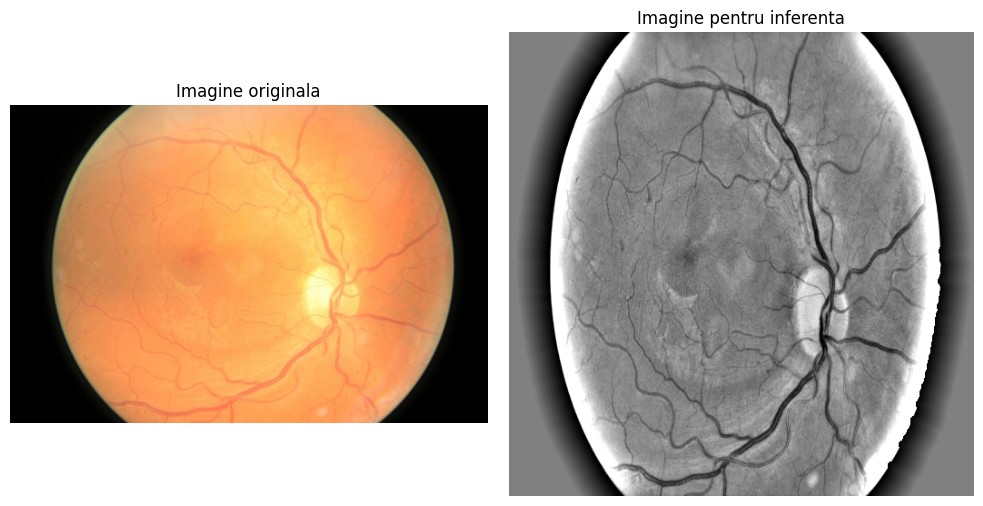

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_image)
axes[0].set_title("Imagine originala")
axes[0].axis("off")

axes[1].imshow(inference_image)
axes[1].set_title("Imagine pentru inferenta")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Predictie

In [34]:
transform = make_inference_transform(input_size)
input_tensor = transform(inference_image).unsqueeze(0).to(DEVICE)

start = time.perf_counter()
with torch.no_grad():
    logits = model(input_tensor)
    probabilities = F.softmax(logits, dim=1)[0]
    confidence, predicted_class = torch.max(probabilities, dim=0)
inference_time_ms = (time.perf_counter() - start) * 1000

predicted_class = int(predicted_class.item())
confidence = float(confidence.item())
probabilities_np = probabilities.detach().cpu().numpy()
top2 = np.sort(probabilities_np)[-2:]
top2_margin = float(top2[-1] - top2[-2]) if len(top2) == 2 else 0.0

print("=" * 60)
print(f"Predictie: clasa {predicted_class} - {CLASS_NAMES[predicted_class]}")
print(f"Confidence: {confidence:.4f} ({confidence * 100:.2f}%)")
print(f"Top-2 margin: {top2_margin:.4f}")
print(f"Timp inferenta: {inference_time_ms:.1f} ms")
print("=" * 60)

for class_id, prob in enumerate(probabilities_np):
    print(f"Clasa {class_id} ({CLASS_NAMES[class_id]}): {prob:.4f} ({prob * 100:.2f}%)")

Predictie: clasa 1 - Retinopatie usoara (Mild)
Confidence: 0.3635 (36.35%)
Top-2 margin: 0.0118
Timp inferenta: 10.7 ms
Clasa 0 (Fara retinopatie (No DR)): 0.2346 (23.46%)
Clasa 1 (Retinopatie usoara (Mild)): 0.3635 (36.35%)
Clasa 2 (Retinopatie moderata (Moderate)): 0.3517 (35.17%)
Clasa 3 (Retinopatie severa (Severe)): 0.0392 (3.92%)
Clasa 4 (Retinopatie proliferativa (Proliferative)): 0.0110 (1.10%)


## Grafic probabilitati

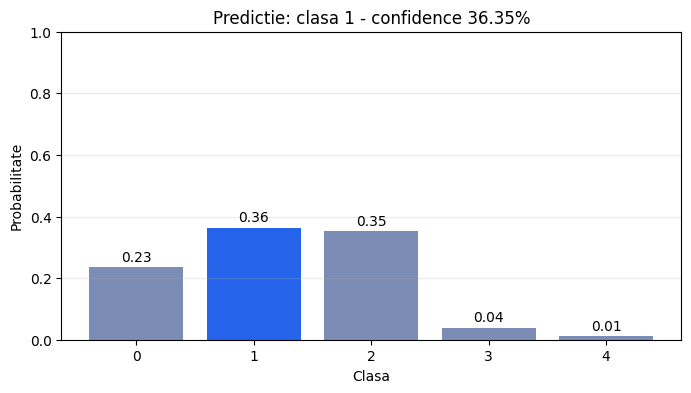

In [35]:
labels = [f"{i}" for i in range(NUM_CLASSES)]
colors = ["#7c8db5"] * NUM_CLASSES
colors[predicted_class] = "#2563eb"

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, probabilities_np, color=colors)
plt.ylim(0, 1)
plt.xlabel("Clasa")
plt.ylabel("Probabilitate")
plt.title(f"Predictie: clasa {predicted_class} - confidence {confidence * 100:.2f}%")
plt.grid(axis="y", alpha=0.25)

for bar, prob in zip(bars, probabilities_np):
    plt.text(bar.get_x() + bar.get_width() / 2, min(prob + 0.02, 0.98), f"{prob:.2f}", ha="center")

plt.show()

In [ ]:
print("OK")